In [2]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;

In [3]:
# Goal of this Notebook is to check if there are Outlier in my data or not

In [4]:
df = pd.read_csv("../datasets/placement.csv")

In [131]:
df.skew()

cgpa                   -0.014530
placement_exam_marks    0.835642
placed                  0.044077
dtype: float64

In [132]:
df.head(5)

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


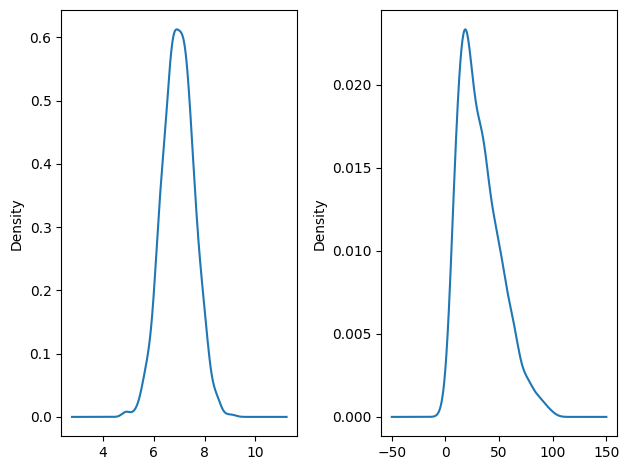

In [133]:
fig, axes = plt.subplots(nrows=1, ncols=2)

df["cgpa"].plot(kind = "density", ax = axes[0]);
df["placement_exam_marks"].plot(kind = "density", ax = axes[1]);

fig.tight_layout()

## Trimming for Removing Outlier

In [134]:
# Helper method to print the value that are outlier using concept of Z-Score
def print_outlier_value(column_name):
    # Calculating Min and Max value for Z-score
    min = df[column_name].mean() - 3*df[column_name].std()
    max = df[column_name].mean() + 3*df[column_name].std()
    # Iterating over the column values
    for val in df[column_name]:
        if val < min or val > max:
            print("Outlier received")
            print(min, val, max)    

In [135]:
# Using vectorization instead of simple loop
def get_outlier_value(column_name):
    # Calculating Min and Max value for Z-score
    mean = df[column_name].mean()
    std = df[column_name].std()
    minimum =  mean - 3*std;
    maximum =  mean + 3*std;
    return df[(df[column_name] < minimum) | (df[column_name] > maximum)]

In [136]:
# Printing Outlier using Z-score that are present in the cgpa column
print_outlier_value("cgpa")

Outlier received
5.113546374602832 4.92 8.808933625397168
Outlier received
5.113546374602832 8.87 8.808933625397168
Outlier received
5.113546374602832 9.12 8.808933625397168
Outlier received
5.113546374602832 4.89 8.808933625397168
Outlier received
5.113546374602832 4.9 8.808933625397168


In [137]:
# Printing Outlier using Z-score that are present in the placement_exam_marks column
print_outlier_value("placement_exam_marks")

Outlier received
-25.167467016763247 94.0 89.61746701676324
Outlier received
-25.167467016763247 93.0 89.61746701676324
Outlier received
-25.167467016763247 90.0 89.61746701676324
Outlier received
-25.167467016763247 90.0 89.61746701676324
Outlier received
-25.167467016763247 96.0 89.61746701676324
Outlier received
-25.167467016763247 90.0 89.61746701676324
Outlier received
-25.167467016763247 97.0 89.61746701676324
Outlier received
-25.167467016763247 100.0 89.61746701676324


In [138]:
outlier_cgpa = get_outlier_value('cgpa')
df_trimming = df.drop(index = outlier_cgpa.index)

In [139]:
df_trimming.shape

(995, 3)

## Using Z-score for Removing Outlier from Normal Distribution'

In [140]:
df['cgpa_zscore'] = (df["cgpa"] - df["cgpa"].mean())/df["cgpa"].std()

In [141]:
removed_column_index = df[(df["cgpa_zscore"] < -3) | (df["cgpa_zscore"] > 3)].index

In [142]:
df_zscore_trimming = df.drop(index = removed_column_index)

In [143]:
df_zscore_trimming

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Using Capping 

In [144]:
mean = df['cgpa'].mean()
std = df['cgpa'].std()
minimum =  mean - 3*std;
maximum =  mean + 3*std;

In [145]:
df['cgpa_capping'] = np.where(
    df["cgpa"] > maximum,
    maximum,
    np.where(
        df["cgpa"] < minimum,
        minimum,
        df['cgpa']
    ))

In [146]:
df

,cgpa,placement_exam_marks,placed,cgpa_zscore,cgpa_capping
0,7.19,26.0,1,0.371425,7.190000
1,7.46,38.0,1,0.809810,7.460000
2,7.54,40.0,1,0.939701,7.540000
3,6.42,8.0,1,-0.878782,6.420000
4,7.23,17.0,0,0.436371,7.230000
...,...,...,...,...,...
995,8.87,44.0,1,3.099150,8.808934
996,9.12,65.0,1,3.505062,8.808934
997,4.89,34.0,0,-3.362960,5.113546
998,8.62,46.0,1,2.693239,8.620000
